## setup

In [1]:
from typing import Optional, Tuple, List, Union, Any, Callable, Dict, Literal, Iterator

from pydantic import BaseModel, HttpUrl

import requests, json, gc
import numpy as np
import matplotlib.pyplot as plt

from decouple import config
from datetime import datetime
from tqdm import tqdm
from io import BytesIO
from PIL import Image

import faiss

In [2]:
DATA_DIR = "data"
INDEX_ID = "20260402163220"
BATCH_SIZE = 64

## models

In [3]:
CategoryType = Literal["top", "accessories", "bottom", "outerwear", "footwear", "dress"]


In [4]:
class Item(BaseModel):
    id: str
    text: str
    category_type: CategoryType
    image_urls: List[HttpUrl]

    def __len__(self) -> int:
        return len(self.image_urls)

    def __getitem__(self, ix: int) -> HttpUrl:
        return self.image_urls[ix]

    def __iter__(self) -> Iterator[HttpUrl]:
        return iter(self.image_urls)

In [5]:
class ScoredItem(Item):
    score: float

## functions

In [6]:
def generate_index_id() -> str:
    return datetime.now().strftime("%Y%m%d%H%M%S")


# generate_index_id()

In [7]:
def load_json(path: str) -> Any:
    with open(path, "r") as f:
        return json.load(f)


def save_json(data: Any, path: str) -> None:
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

In [8]:
def download_image(
    url: str, as_pil: bool = False
) -> Optional[Union[bytes, Image.Image]]:
    try:
        response = requests.get(url, stream=True, timeout=10)
        response.raise_for_status()
        image = BytesIO(response.content)

        if as_pil:
            image = Image.open(image)

        return image

    except:
        return None


In [9]:
def make_subplots(
    n_axes: int, n_cols: int, fig_dims: Optional[Tuple] = (None, None)
) -> Tuple:
    n_rows = int(np.ceil(n_axes / n_cols))

    if fig_dims == (None, None):
        fig_dims = (n_rows * 6, n_cols * 5)

    n_subplots = n_rows * n_cols
    n_empty_axs = n_subplots - n_axes
    empty_axs_idxs = [-i for i in range(1, n_empty_axs + 1)]

    fig, axs = plt.subplots(n_rows, n_cols, figsize=fig_dims)

    if n_subplots > 1:
        axs = axs.ravel()
        for ix in empty_axs_idxs:
            fig.delaxes(axs[ix])

        axs = axs[: (n_subplots - n_empty_axs)]

    return fig, axs


def display_images(
    images: List[Image.Image],
    image_titles: Optional[List] = None,
    title: Optional[str] = None,
    n_cols: int = 4,
    fig_dims: Optional[Tuple[int, int]] = None,
):
    n_axes = len(images)
    n_rows = n_axes // n_cols + 1
    fig_dims = fig_dims if fig_dims else (6 * n_cols, 3 * n_rows)
    fig, axes = make_subplots(n_axes, n_cols, fig_dims)

    if n_axes == 1:
        axes = [axes]

    if image_titles is None:
        image_titles = [None] * n_axes

    if title:
        fig.suptitle(title, fontsize=12)
        fig.subplots_adjust(top=0.80)

    for ax, image, title in zip(axes, images, image_titles):
        try:
            ax.imshow(image)
            ax.axis("off")

            if title:
                ax.set_title(title)
        except:
            pass

In [10]:
def create_np_embedding(text: str, embed_func: Callable) -> np.ndarray:
    embedding = embed_func([text])[0]
    np_embedding = np.array(embedding, dtype=np.float32).reshape(1, -1)
    faiss.normalize_L2(np_embedding)

    return np_embedding

    
def create_np_embeddings(texts: List[str], embed_func: Callable, batch_size: int) -> np.ndarray:
    n, n_success, all_embeddings = 0, 0, []
    loop = tqdm(iterable=range(0, len(texts), batch_size))

    for i in loop:
        n += 1

        try:
            batch = texts[i : i + batch_size]
            batch_embeddings = embed_func(batch)

            if batch_embeddings is not None:
                all_embeddings.extend(batch_embeddings)
                n_success += 1
        
        except Exception as e:
            loop.set_description(str(e))
        
        success_rate = n_success / n
        loop.set_description(f"{success_rate=:.2f}")

    embeddings = np.array(all_embeddings, dtype=np.float32)

    gc.collect()
    del all_embeddings

    return embeddings

In [11]:
def search(
    vector: np.ndarray,
    index: faiss.IndexFlatIP,
    dataset: List[Item],
    top_k: int
) -> List[ScoredItem]:
    scores, indices = index.search(vector, k=top_k)
    results = []

    for score, idx in zip(scores[0], indices[0]):
        item = dataset[idx]

        item = ScoredItem(
            id=item.id,
            text=item.text,
            category_type=item.category_type,
            image_urls=item.image_urls,
            score=score
        )
        
        results.append(item)

    return results

In [20]:
def process_search_results(results: List[ScoredItem], top_k: Optional[int] = None) -> Tuple[List[Image.Image], List[str]]:
    images, image_titles = [], []

    for item in results:
        top_k = top_k if top_k else len(item)
        counter = 0

        for image_url in item.image_urls:
            image = download_image(image_url, as_pil=True)

            if image:
                images.append(image)
                title = f"{item.text}: {item.score:.3f}"
                image_titles.append(title)
                counter += 1

            if counter >= top_k:
                break

    return images, image_titles

## `FashionCLIPEncoder`

In [12]:
class FCLIPEncoder:
    TOKEN = config("HF_API_TOKEN")
    ENDPOINT = "https://precove-fclip-back.hf.space"
    TIMEOUT = 60

    def __init__(self):
        self.endpoint_text = f"{self.ENDPOINT}/encode_texts"
        self.endpoint_image = f"{self.ENDPOINT}/encode_images"

        self.headers = {
            "Content-Type": "application/json",
            "Authorization": f"Bearer {self.TOKEN}",
        }

    def encode_texts(self, texts: List[str]) -> Optional[List[List[float]]]:
        payload = json.dumps({"texts": texts})

        response = requests.request(
            method="POST",
            url=self.endpoint_text,
            headers=self.headers,
            data=payload,
            timeout=self.TIMEOUT,
        )

        return self._parse_response(response)

    def encode_images(self, image_urls: List[str]) -> Optional[List[List[float]]]:
        payload = json.dumps({"urls": image_urls})

        response = requests.request(
            method="POST",
            url=self.endpoint_image,
            headers=self.headers,
            data=payload,
            timeout=self.TIMEOUT,
        )

        return self._parse_response(response)

    def _parse_response(self, response: requests.Response) -> Optional[List[List[float]]]:
        if response.status_code != 200:
            return None

        json_data = response.json()
        if not json_data.get("embeddings"):
            return None

        return json_data["embeddings"]


encoder = FCLIPEncoder()

## data

In [13]:
data = load_json(f"{DATA_DIR}/{INDEX_ID}.json")
dataset = [Item(**record) for record in data]
len(dataset)

5290

In [14]:
num_images = [len(item) for item in dataset]
num_images_avg = np.mean(num_images)
num_images_std = np.std(num_images)
num_images_min = np.min(num_images)
num_images_max = np.max(num_images)
num_images_median = np.median(num_images)

print(f"{num_images_avg=:.2f}")
print(f"{num_images_median=:.2f}")
print(f"{num_images_std=:.2f}")
print(f"{num_images_min=:.2f}")
print(f"{num_images_max=:.2f}")

num_images_avg=1.24
num_images_median=1.00
num_images_std=1.36
num_images_min=1.00
num_images_max=41.00


## FAISS index

In [15]:
try:
    index = faiss.read_index(f"{DATA_DIR}/{INDEX_ID}.faiss")
    print(f"index: {INDEX_ID}.faiss")
    
except:
    texts = [item.text for item in dataset]

    embeddings = create_np_embeddings(
        texts=texts,
        embed_func=encoder.encode_texts,
        batch_size=BATCH_SIZE
    )

    faiss.normalize_L2(embeddings)

    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)

    faiss.write_index(index, f"{DATA_DIR}/{INDEX_ID}.faiss")

print(f"vectors: {index.ntotal}, dim: {index.d}")

success_rate=1.00: 100%|██████████| 83/83 [01:46<00:00,  1.29s/it]


vectors: 5290, dim: 512


## search

### from text

In [24]:
query_text = "electric blue boxy hoodie"

In [25]:
vector = create_np_embedding(query_text, encoder.encode_texts)
results = search(vector, index, dataset, top_k=10)

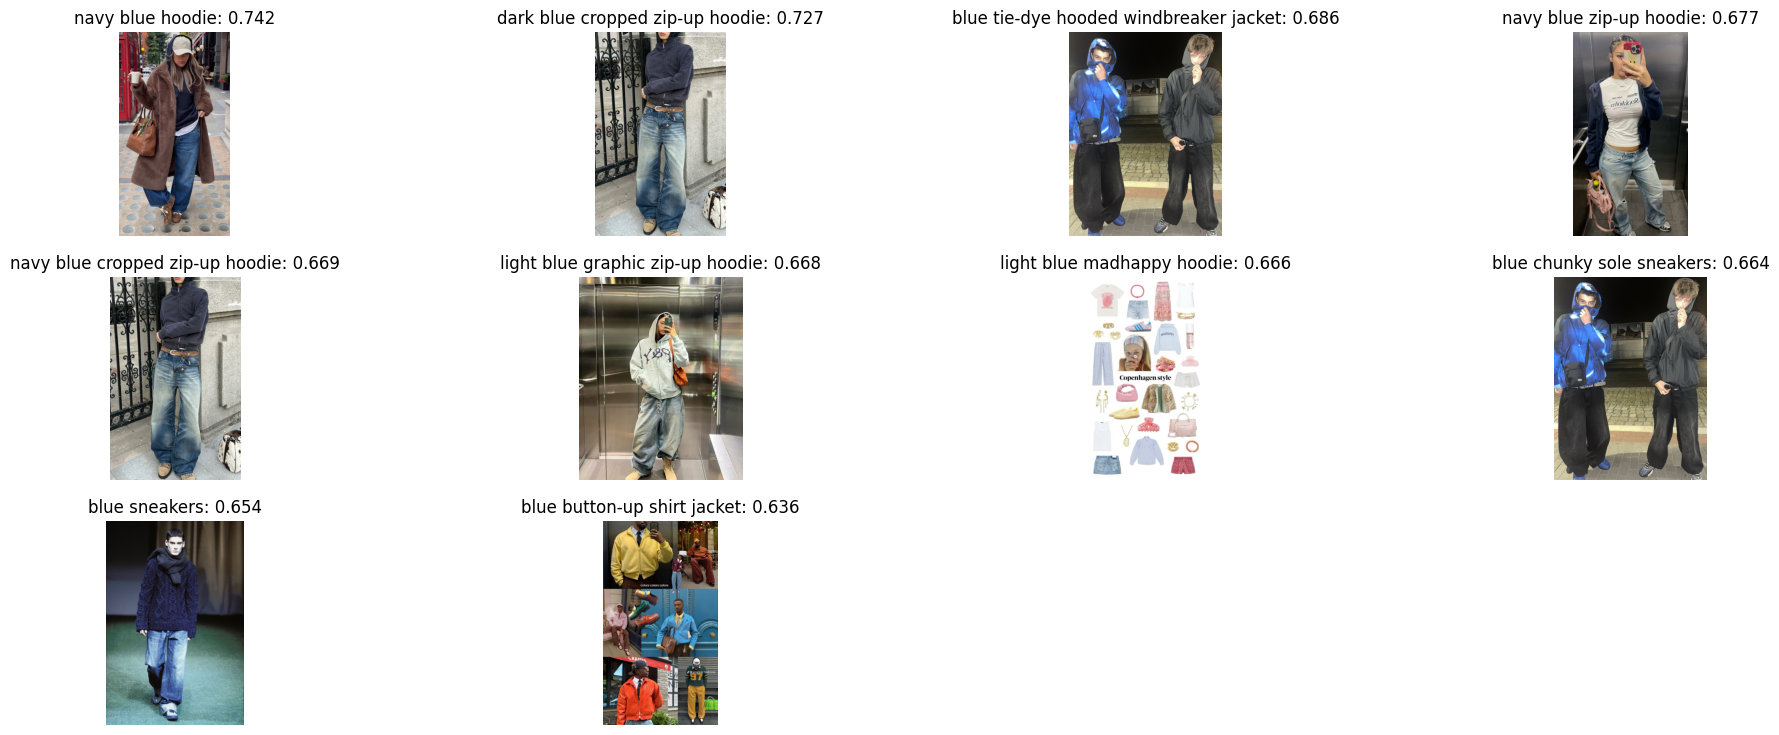

In [26]:
images, image_titles = process_search_results(results, top_k=3)
display_images(images, image_titles); 

### from image

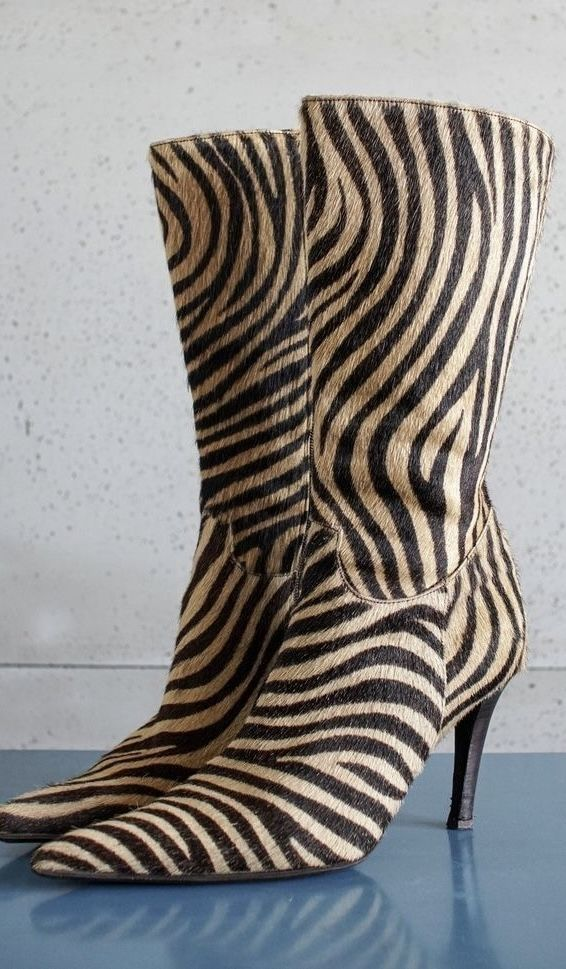

In [30]:
query_image = "https://i.pinimg.com/736x/f3/dd/f6/f3ddf6be887ef2f3f7b4393acd3b7729.jpg"
download_image(query_image, as_pil=True)

In [31]:
vector = create_np_embedding(query_image, encoder.encode_images)
results = search(vector, index, dataset, top_k=10)

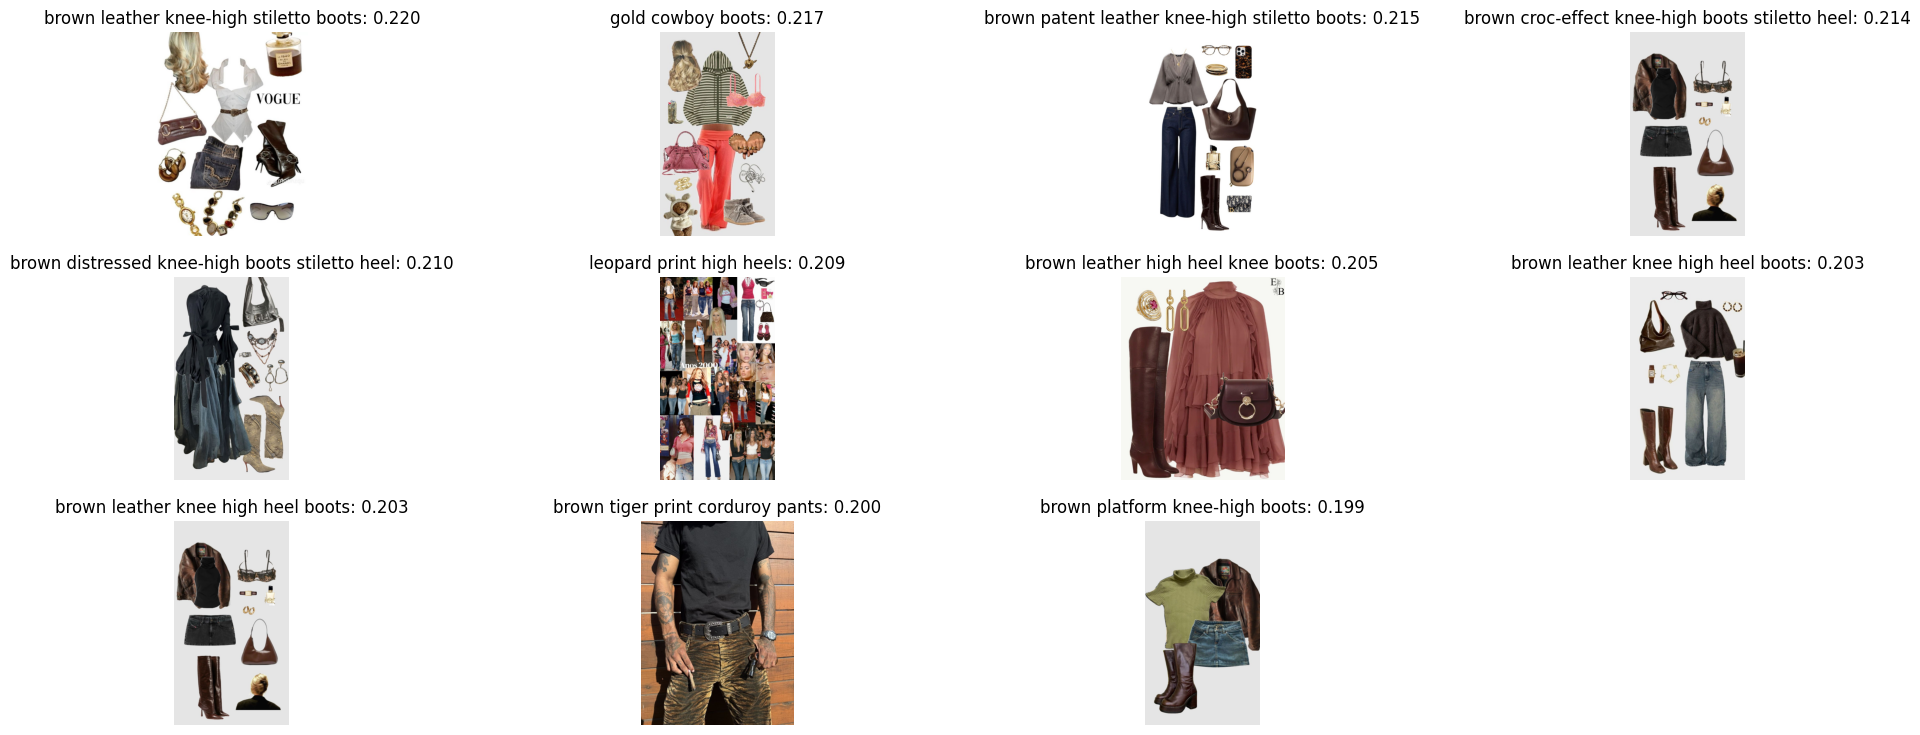

In [32]:
images, image_titles = process_search_results(results, top_k=3)
display_images(images, image_titles); 